# SUPPLY CHAIN PERFORMANCE DASHBOARD IN PYTHON

Import the Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

Load the Dataset

In [2]:
data = pd.read_csv("Dashboard_data.csv")

In [3]:
data_4_dashboard=data.copy()

In [4]:
data_4_dashboard.head()

,OrderID,ProductID,Warehouse,OrderQuantity,LeadTimeDays,ShippingDelayDays,SupplierRating,OrderDate,Month,Year
0,12000,293,Lagos_WH,409,6,6,1.9,2023-04-24,4,2023
1,12001,285,Abuja_WH,483,9,9,1.5,2023-03-19,3,2023
2,12002,186,Lagos_WH,400,18,0,2.8,2023-01-18,1,2023
3,12003,171,Kano_WH,11,9,3,2.2,2023-05-19,5,2023
4,12004,225,Kano_WH,343,23,6,1.9,2023-12-02,12,2023


Total Orders per Warehouse

In [5]:
orders_per_warehouse = data_4_dashboard.groupby('Warehouse')['OrderID'].count()
print(orders_per_warehouse)

Warehouse
Abuja_WH    1523
Kano_WH     1457
Lagos_WH    1520
Name: OrderID, dtype: int64


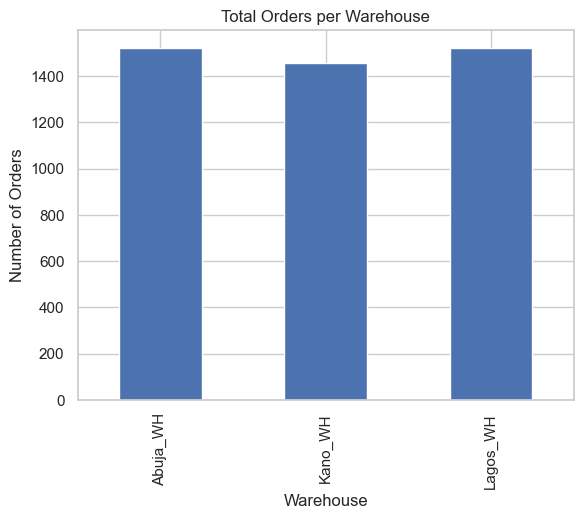

In [6]:
orders_per_warehouse.plot(kind='bar')
plt.title("Total Orders per Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Number of Orders")
plt.show()

Total Quantity Sold per Warehouse

In [7]:
quantity_per_warehouse = data_4_dashboard.groupby('Warehouse')['OrderQuantity'].sum()
print(quantity_per_warehouse)

Warehouse
Abuja_WH    389860
Kano_WH     363600
Lagos_WH    379959
Name: OrderQuantity, dtype: int64


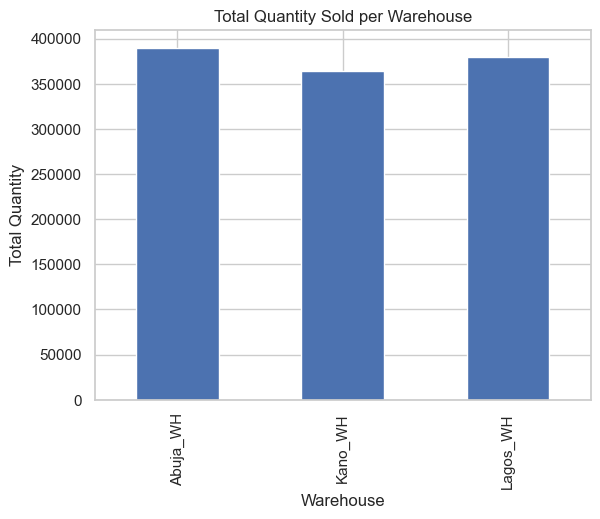

In [8]:
quantity_per_warehouse.plot(kind='bar')
plt.title("Total Quantity Sold per Warehouse")
plt.ylabel("Total Quantity")
plt.show()

Average Lead Time per Warehouse

In [9]:
lead_time = data_4_dashboard.groupby('Warehouse')['LeadTimeDays'].mean()
print(lead_time)

Warehouse
Abuja_WH    15.029547
Kano_WH     15.137268
Lagos_WH    14.609868
Name: LeadTimeDays, dtype: float64


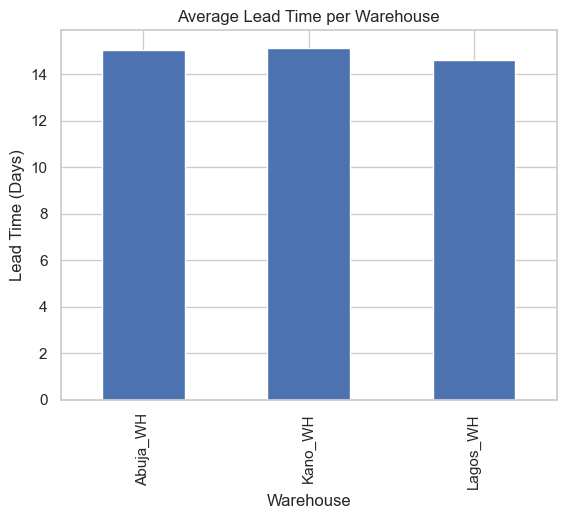

In [10]:
lead_time.plot(kind='bar')
plt.title("Average Lead Time per Warehouse")
plt.ylabel("Lead Time (Days)")
plt.show()

Average Shipping Delay per Warehouse

In [11]:
delay = data_4_dashboard.groupby('Warehouse')['ShippingDelayDays'].mean()
print(delay)

Warehouse
Abuja_WH    4.456336
Kano_WH     4.468771
Lagos_WH    4.462500
Name: ShippingDelayDays, dtype: float64


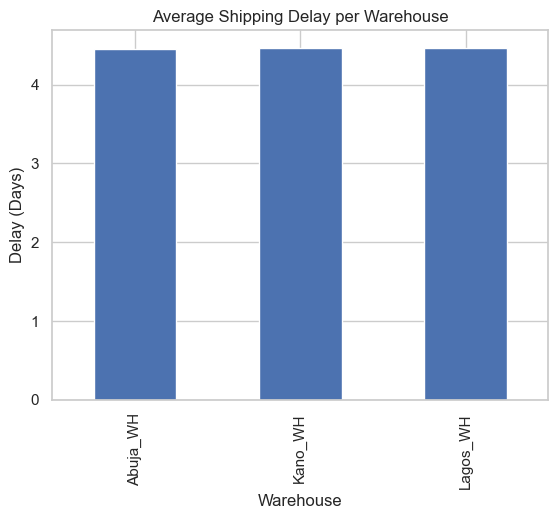

In [12]:
delay.plot(kind='bar')
plt.title("Average Shipping Delay per Warehouse")
plt.ylabel("Delay (Days)")
plt.show()

Average Supplier Rating per Warehouse

In [13]:
rating = data_4_dashboard.groupby('Warehouse')['SupplierRating'].mean()
print(rating)

Warehouse
Abuja_WH    2.944069
Kano_WH     3.008098
Lagos_WH    2.999900
Name: SupplierRating, dtype: float64


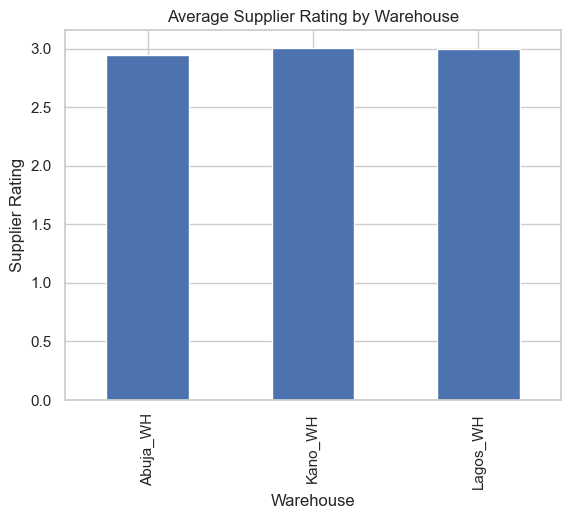

In [14]:
rating.plot(kind='bar')
plt.title("Average Supplier Rating by Warehouse")
plt.ylabel("Supplier Rating")
plt.show()

Product Sales by Warehouse

In [15]:
pivot_table = data_4_dashboard.pivot_table(values='OrderQuantity',
                             index='ProductID',
                             columns='Warehouse',
                             aggfunc='sum')

print(pivot_table)

Warehouse  Abuja_WH  Kano_WH  Lagos_WH
ProductID                             
100            1834     1551      2126
101            2639      866      1038
102            1491     4077      1446
103            2262     1605      2131
104            1901     1034       743
...             ...      ...       ...
295            1364     1625       753
296            1428     1975       512
297            1482      956      1349
298            2723     3563      2510
299             570     1966      2073

[200 rows x 3 columns]


In [16]:
pivot = data_4_dashboard.pivot_table(values='OrderQuantity',
                       index='ProductID',
                       columns='Warehouse',
                       aggfunc='sum')

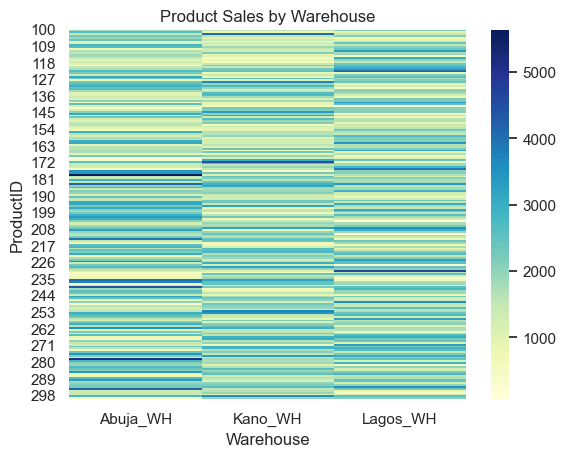

In [17]:
sns.heatmap(pivot, cmap='YlGnBu')
plt.title("Product Sales by Warehouse")
plt.show()